<a href="https://colab.research.google.com/github/AarnavSinghal/AarnavSinghal/blob/main/Stock_return_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Managing the Zip file**

In [92]:
import os
import zipfile


print("Files in /content:", os.listdir("/content"))

zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("\nExtraction complete!")

print("\nFiles inside /content/dataset:")
print(os.listdir(extract_path)[:30])


Files in /content: ['.config', 'test_predictions.csv', 'archive.zip', 'dataset', 'sample_data']

Extraction complete!

Files inside /content/dataset:
['__MACOSX', 'archive']


In [93]:
import zipfile

zip_path = "/content/archive.zip"

print("Contents of archive.zip:\n")
with zipfile.ZipFile(zip_path, 'r') as z:
    for name in z.namelist()[:50]:
        print(name)


Contents of archive.zip:

archive/
__MACOSX/._archive
archive/.DS_Store
__MACOSX/archive/._.DS_Store
archive/symbols_valid_meta.csv
__MACOSX/archive/._symbols_valid_meta.csv
archive/stocks/
__MACOSX/archive/._stocks
archive/etfs/
__MACOSX/archive/._etfs
archive/stocks/RIV.csv
__MACOSX/archive/stocks/._RIV.csv
archive/stocks/ANTE.csv
__MACOSX/archive/stocks/._ANTE.csv
archive/stocks/CSCO.csv
__MACOSX/archive/stocks/._CSCO.csv
archive/stocks/PRI.csv
__MACOSX/archive/stocks/._PRI.csv
archive/stocks/NZF.csv
__MACOSX/archive/stocks/._NZF.csv
archive/stocks/HLNE.csv
__MACOSX/archive/stocks/._HLNE.csv
archive/stocks/UNT.csv
__MACOSX/archive/stocks/._UNT.csv
archive/stocks/HUBS.csv
__MACOSX/archive/stocks/._HUBS.csv
archive/stocks/GPL.csv
__MACOSX/archive/stocks/._GPL.csv
archive/stocks/SBGI.csv
__MACOSX/archive/stocks/._SBGI.csv
archive/stocks/UFCS.csv
__MACOSX/archive/stocks/._UFCS.csv
archive/stocks/TEAF.csv
__MACOSX/archive/stocks/._TEAF.csv
archive/stocks/RJZ.csv
__MACOSX/archive/stocks/.

In [15]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_root = "/content/dataset"

os.makedirs(extract_root, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_root)

print("Extraction complete!")

print("\nListing folders inside /content/dataset:")
print(os.listdir(extract_root))


Extraction complete!

Listing folders inside /content/dataset:
['__MACOSX', 'archive']


In [16]:
import os

stock_path = "/content/dataset/archive/stocks"

print("Does stocks folder exist?", os.path.exists(stock_path))
print("\nFirst 40 files in stocks:")
print(os.listdir(stock_path)[:40])


Does stocks folder exist? True

First 40 files in stocks:
['AUTO.csv', 'NTWK.csv', 'FOE.csv', 'BDTX.csv', 'NTB.csv', 'PRH.csv', 'WMC.csv', 'IFMK.csv', 'LIZI.csv', 'WEX.csv', 'CPHI.csv', 'SPWH.csv', 'CUK.csv', 'SYBX.csv', 'PRAA.csv', 'HUBG.csv', 'PTCT.csv', 'PNF.csv', 'GDV.csv', 'NVDA.csv', 'SOJA.csv', 'INPX.csv', 'THS.csv', 'TATT.csv', 'VZ.csv', 'PWOD.csv', 'GWRS.csv', 'APAM.csv', 'TFII.csv', 'AQST.csv', 'ENX.csv', 'MTNB.csv', 'ROG.csv', 'BVSN.csv', 'HCCHU.csv', 'ONCT.csv', 'ARTNA.csv', 'COWN.csv', 'CLDR.csv', 'BATRK.csv']


#**Loding Dataset,tickers etc.**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


In [18]:
TARGET = "NVDA"
MARKET = "VZ"
PEERS = ["WEX", "HUBG", "THS", "PTCT", "SPWH"]

DATA_PATH = "/content/dataset/archive/stocks"


In [19]:
def load_csv(ticker):
    path = f"{DATA_PATH}/{ticker}.csv"
    if not os.path.exists(path):
        raise FileNotFoundError(f"Ticker {ticker} CSV not found at {path}")

    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    return df


In [20]:
tickers = [TARGET, MARKET] + PEERS

raw = {}
for t in tickers:
    raw[t] = load_csv(t)

raw[TARGET].head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,1999-01-22,1.750000,1.953125,1.552083,1.640625,1.509998,67867200.0
1,1999-01-25,1.770833,1.833333,1.640625,1.812500,1.668188,12762000.0
2,1999-01-26,1.833333,1.869792,1.645833,1.671875,1.538759,8580000.0
3,1999-01-27,1.677083,1.718750,1.583333,1.666667,1.533965,6109200.0
4,1999-01-28,1.666667,1.677083,1.651042,1.661458,1.529172,5688000.0


In [21]:
for t in tickers:
    df = raw[t]
    print(f"{t}: {df['Date'].min().date()} → {df['Date'].max().date()}, rows={len(df)}")


NVDA: 1999-01-22 → 2020-04-01, rows=5334
VZ: 1983-11-21 → 2020-04-01, rows=9166
WEX: 2005-02-16 → 2020-04-01, rows=3807
HUBG: 1996-03-13 → 2020-04-01, rows=6055
THS: 2005-06-28 → 2020-04-01, rows=3716
PTCT: 2013-06-20 → 2020-04-01, rows=1708
SPWH: 2014-04-17 → 2020-04-01, rows=1500


#**Cleaning, Visualizing etc.**

In [22]:
prices = {}

for t in raw:
    df = raw[t][["Date", "Adj Close"]].copy()
    df.rename(columns={"Adj Close": t}, inplace=True)
    prices[t] = df


from functools import reduce

merged = reduce(
    lambda left, right: pd.merge(left, right, on="Date", how="inner"),
    prices.values()
)

merged.head()


,Date,NVDA,VZ,WEX,HUBG,THS,PTCT,SPWH
0,2014-04-17,17.647408,36.734543,91.779999,42.860001,72.150002,18.780001,9.75
1,2014-04-21,17.790030,37.027809,91.650002,44.970001,73.070000,18.580000,9.50
2,2014-04-22,17.942162,36.981506,93.279999,45.419998,74.050003,20.719999,9.66
3,2014-04-23,18.151350,36.603359,92.320000,44.880001,74.349998,18.799999,9.47
4,2014-04-24,18.312984,35.715855,92.220001,45.000000,73.930000,18.830000,10.22


In [23]:
returns = merged.set_index("Date").pct_change().dropna()
returns.head()


,NVDA,VZ,WEX,HUBG,THS,PTCT,SPWH
Date,,,,,,,
2014-04-21,0.008082,0.007983,-0.001416,0.049230,0.012751,-0.010650,-0.025641
2014-04-22,0.008552,-0.001250,0.017785,0.010007,0.013412,0.115178,0.016842
2014-04-23,0.011659,-0.010225,-0.010292,-0.011889,0.004051,-0.092664,-0.019669
2014-04-24,0.008905,-0.024247,-0.001083,0.002674,-0.005649,0.001596,0.079197
2014-04-25,-0.027518,-0.007346,-0.014639,-0.011111,-0.007440,-0.048858,0.025440


In [24]:
print("Summary Statistics:\n")
display(returns.describe().T[["mean", "std", "min", "max"]])


Summary Statistics:



,mean,std,min,max
NVDA,0.002127,0.027557,-0.187559,0.298067
VZ,0.000309,0.011439,-0.066205,0.076802
WEX,0.000273,0.022694,-0.227915,0.182812
HUBG,0.000246,0.021169,-0.149498,0.126103
THS,-0.000087,0.021439,-0.351567,0.123760
PTCT,0.002204,0.056402,-0.616419,0.883333
SPWH,0.000147,0.032201,-0.169173,0.254335


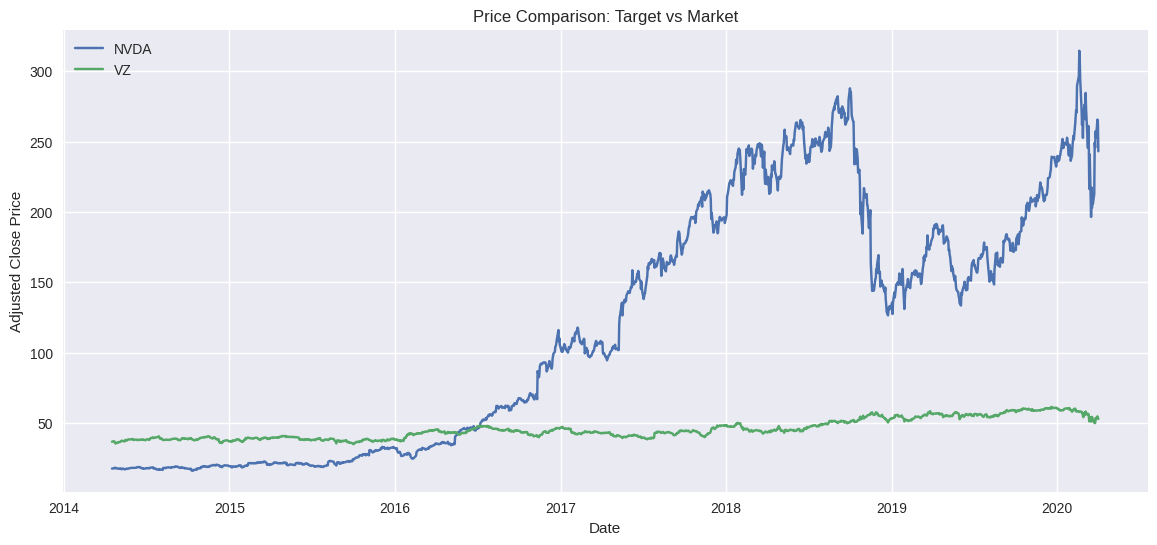

In [25]:
plt.figure(figsize=(14, 6))
for t in [TARGET, MARKET]:
    plt.plot(merged["Date"], merged[t], label=t)

plt.title("Price Comparison: Target vs Market")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.show()


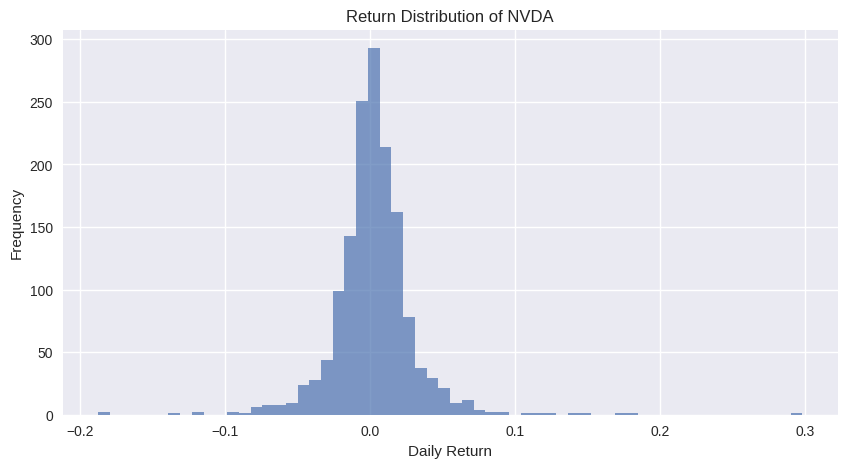

In [26]:
plt.figure(figsize=(10,5))
plt.hist(returns[TARGET], bins=60, alpha=0.7)
plt.title(f"Return Distribution of {TARGET}")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


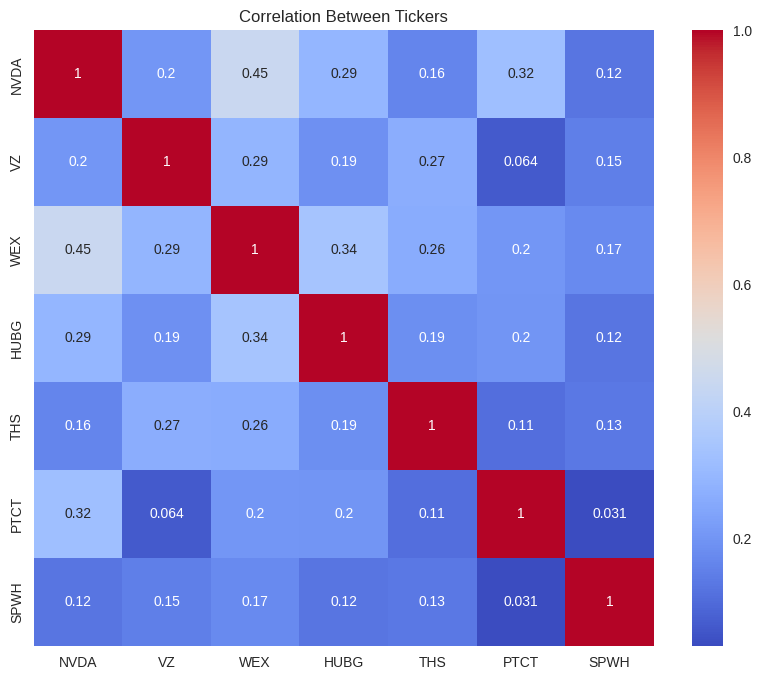

In [27]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Tickers")
plt.show()


#**Feature Engineering, Train test split**

In [74]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

fe = returns.copy()
fe.index = pd.to_datetime(fe.index)

TARGET = "NVDA"
PEERS = ["VZ", "WEX", "HUBG", "THS", "PTCT", "SPWH"]

universe = [TARGET] + PEERS
fe["market_ret"] = fe[universe].mean(axis=1)
MARKET = "market_ret"

fe["target_next_day"] = fe[TARGET].shift(-1)

train_for_peers = fe.loc["2018"]
corrs = train_for_peers[PEERS + [TARGET]].corr()[TARGET].drop(TARGET)
K = 5
top_peers = list(corrs.abs().sort_values(ascending=False).head(K).index)
print("Top peer tickers:", top_peers)

fe["sector_ret"] = fe[top_peers].mean(axis=1)


Top peer tickers: ['WEX', 'HUBG', 'PTCT', 'THS', 'SPWH']


In [75]:

for lag in range(1, 6):
    fe[f"lag_{lag}"] = fe[TARGET].shift(lag)

for w in [5, 20, 63]:
    fe[f"roll_mean_{w}"] = fe[TARGET].rolling(w).mean()
    fe[f"roll_vol_{w}"] = fe[TARGET].rolling(w).std()


In [76]:
target_raw = raw[TARGET].copy()
target_raw.index = pd.to_datetime(target_raw["Date"])

fe["range_hl"] = (target_raw["High"] - target_raw["Low"]) / target_raw["Close"]
fe["range_hl_z20"] = fe["range_hl"].rolling(20).apply(
    lambda x: (x[-1] - x.mean()) / x.std() if x.std() > 0 else 0
)

target_raw["log_vol"] = np.log(target_raw["Volume"])
fe["log_vol"] = target_raw["log_vol"]
fe["vol_z21"] = fe["log_vol"].rolling(21).apply(
    lambda x: (x[-1] - x.mean()) / x.std() if x.std() > 0 else 0
)
fe["vol_delta5"] = fe["log_vol"].diff(5)
fe["vol_delta20"] = fe["log_vol"].diff(20)


/tmp/ipython-input-379190990.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: (x[-1] - x.mean()) / x.std() if x.std() > 0 else 0
/tmp/ipython-input-379190990.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: (x[-1] - x.mean()) / x.std() if x.std() > 0 else 0


In [77]:
betas_mkt = []
betas_sec = []
resids = []

r_i = fe[TARGET]
r_m = fe[MARKET]
r_s = fe["sector_ret"]

for t in range(len(fe)):
    if t < 30:
        betas_mkt.append(np.nan)
        betas_sec.append(np.nan)
        resids.append(np.nan)
        continue

    X = np.column_stack([r_m.iloc[:t], r_s.iloc[:t]])
    X = sm.add_constant(X)
    y = r_i.iloc[:t]

    model = sm.OLS(y, X).fit()

    betas_mkt.append(model.params.iloc[1])
    betas_sec.append(model.params.iloc[2])


    X_today = np.array([1, r_m.iloc[t], r_s.iloc[t]])
    pred = np.dot(X_today, model.params.values)
    resids.append(r_i.iloc[t] - pred)

fe["beta_mkt"] = betas_mkt
fe["beta_sec"] = betas_sec
fe["idio_resid"] = resids


In [78]:
fe = fe.dropna()

train = fe.loc["2018"]
val   = fe.loc["2019"]
test  = fe.loc["2020-01-01":"2020-03-31"]

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)


Train shape: (251, 30)
Val shape: (252, 30)
Test shape: (62, 30)


#**Ensamble**

In [82]:
from sklearn.preprocessing import StandardScaler

feature_cols = [col for col in train.columns if col not in ["target_next_day"]]

X_train = train[feature_cols]
y_train = train["target_next_day"]

X_val = val[feature_cols]
y_val = val["target_next_day"]

X_test = test[feature_cols]
y_test = test["target_next_day"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [83]:
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

en = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
en.fit(X_train_scaled, y_train)
en_val_pred = en.predict(X_val_scaled)

rf = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
rf_val_pred = rf.predict(X_val)

gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
gb_val_pred = gb.predict(X_val)


In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def sign_accuracy(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

models_val = {
    "ElasticNet": en_val_pred,
    "RandomForest": rf_val_pred,
    "GBRT": gb_val_pred
}

for name, pred in models_val.items():
    mae_val = mean_absolute_error(y_val, pred)
    rmse_val = rmse(y_val, pred)
    s_acc = sign_accuracy(y_val, pred)
    print(f"{name} | MAE: {mae_val:.5f} | RMSE: {rmse_val:.5f} | SignAcc: {s_acc:.3f}")


ElasticNet | MAE: 0.01876 | RMSE: 0.02578 | SignAcc: 0.448
RandomForest | MAE: 0.01907 | RMSE: 0.02650 | SignAcc: 0.476
GBRT | MAE: 0.02072 | RMSE: 0.02792 | SignAcc: 0.472


In [85]:
from sklearn.linear_model import Lasso

X_meta_train = np.column_stack([en_val_pred, rf_val_pred, gb_val_pred])
meta = Lasso(alpha=0.001, random_state=42)
meta.fit(X_meta_train, y_val)

en_test_pred = en.predict(X_test_scaled)
rf_test_pred = rf.predict(X_test)
gb_test_pred = gb.predict(X_test)

X_meta_test = np.column_stack([en_test_pred, rf_test_pred, gb_test_pred])
stack_test_pred = meta.predict(X_meta_test)

stack_val_pred = meta.predict(X_meta_train)
print("Stacking Sign Accuracy:", sign_accuracy(y_val, stack_val_pred))


Stacking Sign Accuracy: 0.5476190476190477


In [86]:
from scipy.optimize import minimize

def mae_weights(weights):
    pred = weights[0]*en_val_pred + weights[1]*rf_val_pred + weights[2]*gb_val_pred
    return mean_absolute_error(y_val, pred)

constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0,1)]*3
res = minimize(mae_weights, [1/3,1/3,1/3], bounds=bounds, constraints=constraints)
w_opt = res.x
print("Optimal weights:", w_opt)

weighted_test_pred = w_opt[0]*en_test_pred + w_opt[1]*rf_test_pred + w_opt[2]*gb_test_pred


Optimal weights: [0.33333333 0.33333333 0.33333333]


In [87]:
def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "SignAcc": sign_accuracy(y_true, y_pred)
    }

test_preds = {
    "ElasticNet": en_test_pred,
    "RandomForest": rf_test_pred,
    "GBRT": gb_test_pred,
    "Stacking": stack_test_pred,
    "WeightedAvg": weighted_test_pred
}

metrics = {name: evaluate_model(y_test, pred) for name, pred in test_preds.items()}
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)


                   MAE      RMSE   SignAcc
ElasticNet    0.039175  0.054453  0.451613
RandomForest  0.037059  0.052492  0.661290
GBRT          0.038207  0.054658  0.612903
Stacking      0.038936  0.054392  0.548387
WeightedAvg   0.036970  0.052923  0.629032


#**Decision and Visualization**

In [96]:
preds = stack_test_pred
threshold_buy = 0.002
threshold_sell = -0.002

decisions = []
for r in preds:
    if r >= threshold_buy:
        decisions.append("Buy")
    elif r <= threshold_sell:
        decisions.append("Sell")
    else:
        decisions.append("Hold")

test_out = test.copy()
test_out["r_hat_next"] = preds
test_out["p_hat_next"] = test_out[TARGET] * (1 + test_out["r_hat_next"])
test_out["decision"] = decisions

test_out[["r_hat_next","p_hat_next","decision"]].head()


,r_hat_next,p_hat_next,decision
Date,,,
2020-01-02,0.002592,0.019643,Buy
2020-01-03,0.002592,-0.016047,Buy
2020-01-06,0.002592,0.004204,Buy
2020-01-07,0.002592,0.012138,Buy
2020-01-08,0.002592,0.001880,Buy


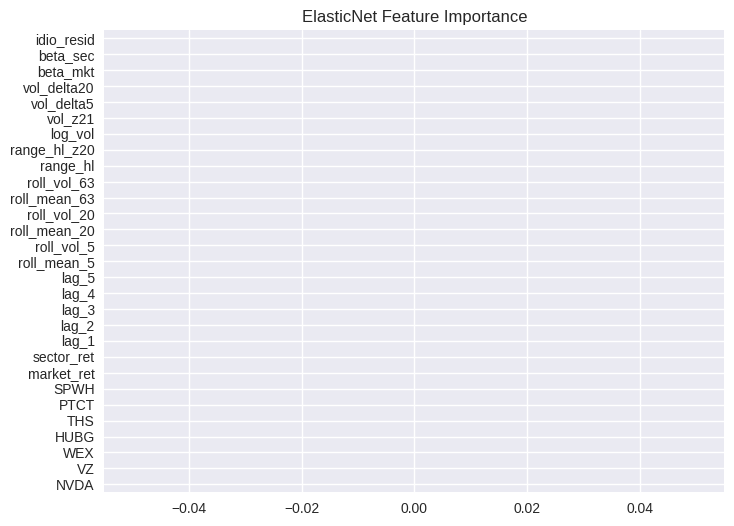

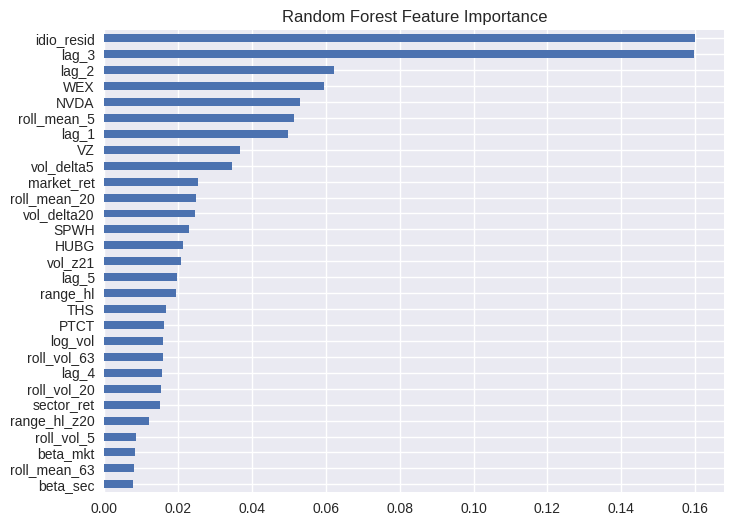

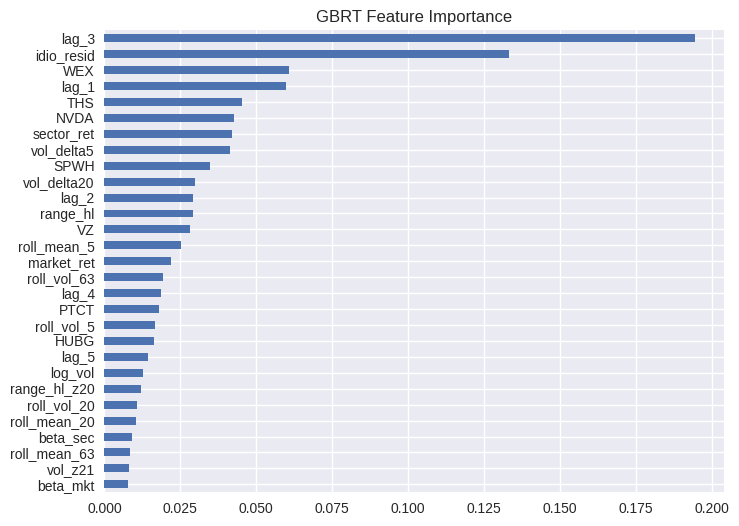

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

en_coef = pd.Series(en.coef_, index=feature_cols)
en_coef.sort_values().plot(kind='barh', figsize=(8,6), title="ElasticNet Feature Importance")
plt.show()

rf_imp = pd.Series(rf.feature_importances_, index=feature_cols)
rf_imp.sort_values().plot(kind='barh', figsize=(8,6), title="Random Forest Feature Importance")
plt.show()

gb_imp = pd.Series(gb.feature_importances_, index=feature_cols)
gb_imp.sort_values().plot(kind='barh', figsize=(8,6), title="GBRT Feature Importance")
plt.show()


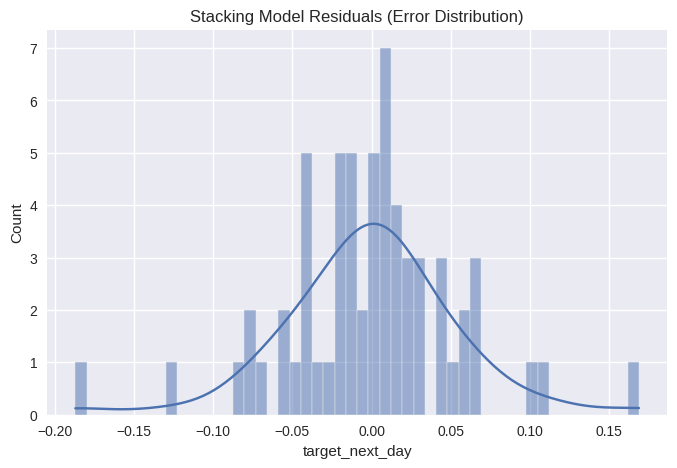

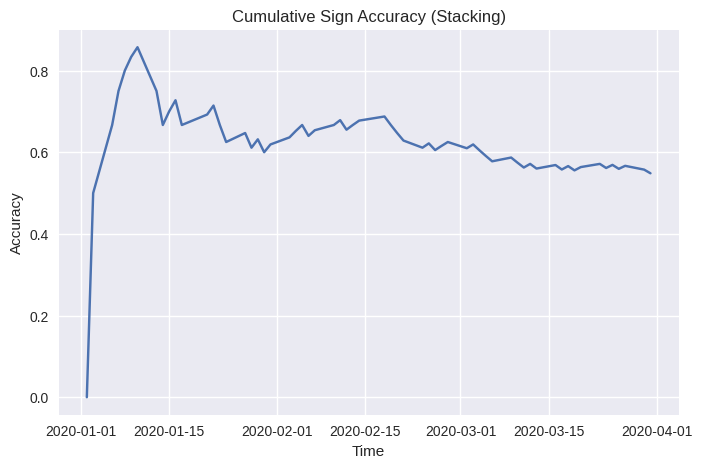

In [98]:
residuals = y_test - stack_test_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Stacking Model Residuals (Error Distribution)")
plt.show()

signs = np.sign(y_test) == np.sign(stack_test_pred)
cumsum_signs = signs.cumsum() / np.arange(1, len(signs)+1)

plt.figure(figsize=(8,5))
plt.plot(cumsum_signs)
plt.title("Cumulative Sign Accuracy (Stacking)")
plt.xlabel("Time")
plt.ylabel("Accuracy")
plt.show()


In [1]:
notes = ["synthetic market/peer sector"]*len(test_out)

output_csv = test_out[["r_hat_next", "p_hat_next", "decision"]].copy()
output_csv["ticker"] = TARGET
output_csv["date"] = test_out.index
output_csv["notes"] = notes

output_csv = output_csv[["date","ticker","r_hat_next","p_hat_next","decision","notes"]]
output_csv.to_csv("test_predictions.csv", index=False)
print("Test predictions saved as test_predictions.csv")


NameError: name 'test_out' is not defined